# Att upptäcka abonnenters dataanvändningssegment med PROC FASTCLUS

## Sammanfattning

Ett team för telekomanalys vill segmentera sin mobilabonnentbas efter **månatlig dataförbrukning** utan att införa godtyckliga GB-trösklar. Med **PROC FASTCLUS** — SAS högpresterande *k*-means-klustringsprocedur — låter vi datan självständigt dela in sig i latenta förbrukningsklasser (lätta, måttliga och tunga dataanvändare). FASTCLUS hittar varje segments centrum, tilldelar varje abonnent till det närmaste och rapporterar hur tydligt segmenten separerar — vilket omvandlar ett enda kontinuerligt förbrukningsmått till en handlingsbar, datadriven segmentering för planutformning och riktad marknadsföring.

## Datakällor

All data genereras inline av det första DATA-steget — det finns inga externa filer eller nätverksanrop. Abonnenter dras från en population med tre förbrukningskomponenter så att de återfunna segmenten kan valideras mot en känd sanning.

| Dataset | Rader | Variabel | Typ | Beskrivning |
|---------|------|----------|------|-------------|
| `subscribers` | 1 500 | `id` | Num | Abonnentidentifierare (1–1500) |
| `subscribers` | 1 500 | `data_gb` | Num | Månatlig mobil dataförbrukning, i GB (måttet vi klustrar på) |
| `subscribers` | 1 500 | `segment_true` | Char | Latent segment som används för att *generera* värdet (Lätt ≈ N(3,1²) 50 %, Måttlig ≈ N(12,3²) 35 %, Tung ≈ N(35,8²) 15 %); hålls bara undan för att validera de återfunna segmenten — en verklig analytiker skulle inte observera det |

# Att upptäcka abonnenters dataanvändningssegment

Mobiloperatörer har sällan en tydlig etikett som säger *"det här är en tung dataanvändare."* Det de har är ett kontinuerligt mått — gigabyte förbrukade per månad — vars fördelning är **multimodal**: kluster av lätta, måttliga och poweranvändare överlappar på en enda axel. **Klusteranalys** behandlar den enda kolumnen som ett geometriproblem: den lokaliserar de naturliga tyngdpunkterna i förbrukningsfördelningen och tilldelar varje abonnent till den närmaste, utan handplockade gränsvärden.

I denna notebook:

1. Genererar vi en realistisk syntetisk abonnentbas vars dataförbrukning kommer från tre dolda segment.
2. Inspekterar vi den marginella förbrukningsfördelningen för att bekräfta att den är multimodal.
3. Standardiserar vi måttet och kör **PROC FASTCLUS** för att dela in abonnenter i tre förbrukningssegment.
4. Profilerar vi varje upptäckt segment på den ursprungliga GB-skalan och validerar sedan återfinningen mot den kända sanningen.

Etiketten `segment_true` genereras enbart så att vi kan bedöma klustringen i slutet — i produktion skulle den inte finnas.

In [1]:
/* Syntetisera en abonnentbas från tre latenta förbrukningssegment. */
/* Lättanvändare dominerar; en liten svans av tunga användare driver merparten av intäkterna. */
data subscribers;
   CALL streaminit(20260531);
   LÄNGD segment_true $10;
   GÖR id = 1 TILL 1500;
      u = rand('uniform');
      OM u < 0.50 SÅ GÖR;                 /* ~50% lätta användare        */
         segment_true = 'Lätt';
         data_gb = rand('normal', 3.0, 1.0);
      SLUT;
      ANNARS OM u < 0.85 SÅ GÖR;            /* ~35% måttliga användare     */
         segment_true = 'Måttlig';
         data_gb = rand('normal', 12.0, 3.0);
      SLUT;
      ANNARS GÖR;                             /* ~15% tunga användare/poweranvändare  */
         segment_true = 'Tung';
         data_gb = rand('normal', 35.0, 8.0);
      SLUT;
      OM data_gb < 0.1 SÅ data_gb = 0.1; /* förbrukning kan inte vara negativ */
      UTDATA;
   SLUT;
   BEHÅLL id data_gb segment_true;
KÖR;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## En första titt på den marginella fördelningen

Innan klustring, sammanfatta den enda responsvariabeln. Den stora spridningen och avståndet mellan medelvärdet och merparten av de lätta användarna är tydliga tecken på en underliggande blandning av segment — en enda förbrukningsnivå skulle inte kunna återge både det täta klustret med låg förbrukning och den långa svansen med hög förbrukning.

In [2]:
PROCEDUR MEDELVÄRDEN data=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   ETIKETT data_gb="Månatlig dataförbrukning (GB)";
   VARIABEL data_gb;
KÖR;

                                                  The MEANS Procedure

 Variable  Label                                   N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -------------------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Månatlig dataförbrukning (GB)         100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 -------------------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Histogrammet gör multimodaliteten synlig: en hög topp för lätta användare nära 3 GB, en måttlig puckel nära 12 GB och en gles svans av tunga användare som sträcker sig förbi 30 GB. Dessa tre moder är exakt de segment vi ska be klustringen att återfinna. Kärndensitetskurvan följer samma blandade form.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


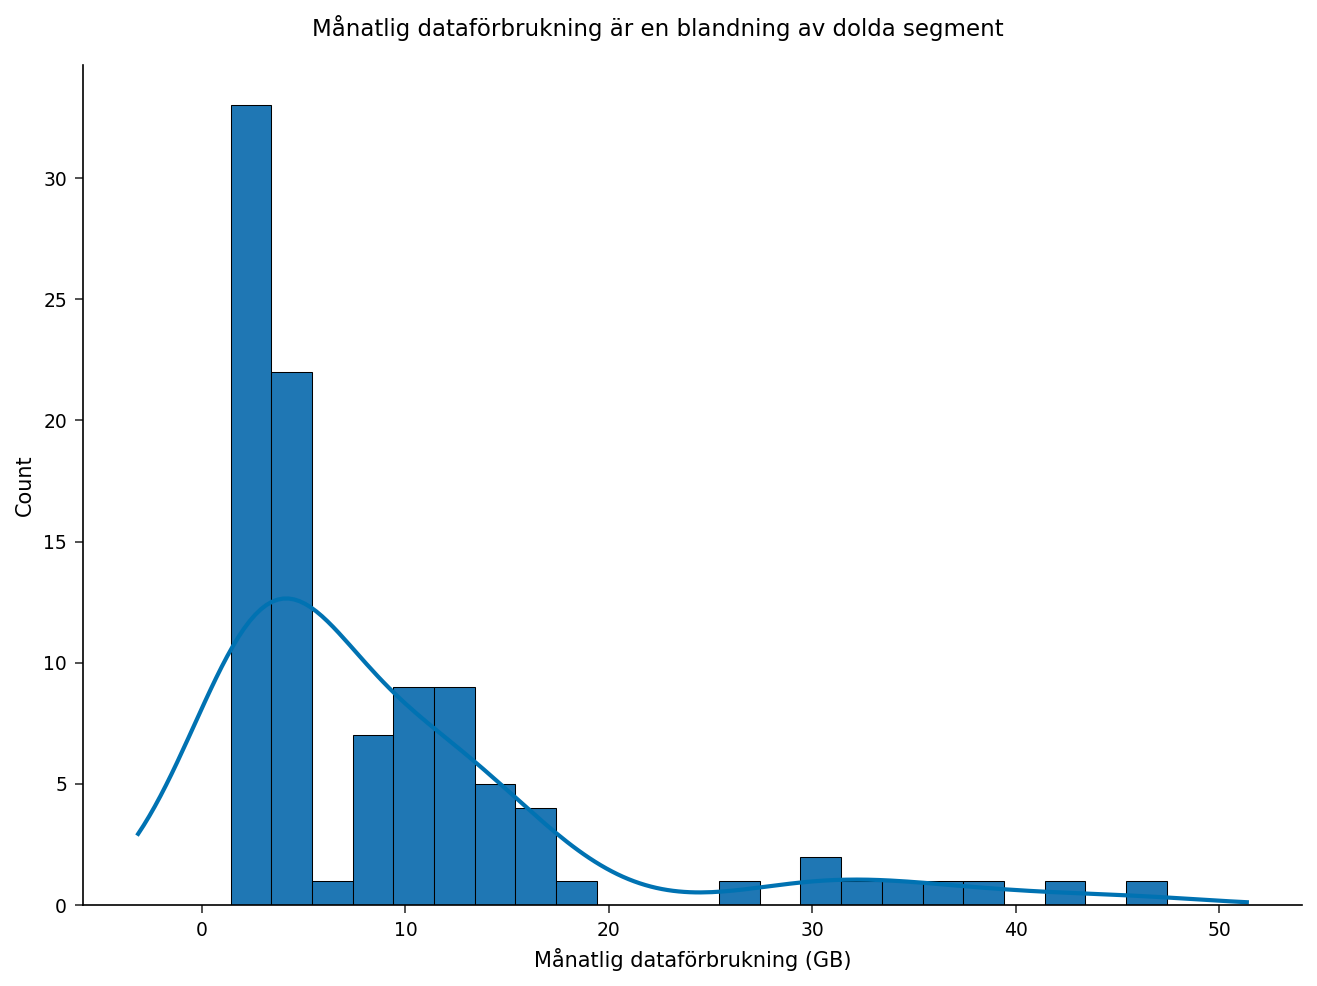

In [3]:
ODS GRAPHICS ON;
PROCEDUR SGPLOT data=subscribers;
   TITEL "Månatlig dataförbrukning är en blandning av dolda segment";
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS ETIKETT="Månatlig dataförbrukning (GB)";
KÖR;
TITEL;
ODS GRAPHICS OFF;

## Att sätta förbrukningen på en gemensam skala

*k*-means delar in punkter efter euklidiskt avstånd, så variabelns råskala styr resultatet. Med ett enda mått innebär detta bara att axeln centreras om, men att standardisera till medelvärde 0 / standardavvikelse 1 med **PROC STANDARD** är den vana som håller arbetsflödet korrekt så snart ett andra förbrukningsmått (samtalsminuter, roamingdagar) läggs till. Vi klustrar på den standardiserade kolumnen och rapporterar resultaten tillbaka på den ursprungliga GB-skalan.

In [4]:
PROCEDUR STANDARD data=subscribers out=subs_std mean=0 std=1;
   VARIABEL data_gb;
KÖR;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Att dela in abonnenter i tre förbrukningssegment

Vägledda av domänkunskap om lätta / måttliga / tunga nivåer ber vi **PROC FASTCLUS** om `MAXCLUSTERS=3`. Proceduren initierar tre centrum, tilldelar varje abonnent till det närmaste, räknar om centrumen och itererar tills tilldelningarna slutar ändras (`CONVERGE=` med ett `MAXITER=`-tak). `SEED=` gör initieringen reproducerbar. `OUT=`-datasetet bär varje abonnents `CLUSTER`-etikett och dess `DISTANCE` till det tilldelade centrumet; `MEAN=` skriver segmentens centroider.

Läs procedurens diagnostik för separationskvalitet: ett högt **R-kvadrat** (andelen av den totala förbrukningsvariansen som segmenten förklarar) och ett stort **Pseudo F** indikerar båda väl separerade, kompakta segment.

In [5]:
PROCEDUR FASTCLUS data=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   ETIKETT data_gb="Standardiserad dataförbrukning (GB)";
   VARIABEL data_gb;
   TITEL "Tre förbrukningssegment via k-means";
KÖR;
TITEL;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Att profilera de upptäckta segmenten

Klusteretiketter blir bara användbara i praktiken när vi beskriver varje segment i affärstermer. Vi sammanfogar tilldelningarna tillbaka med den ursprungliga (icke-standardiserade) förbrukningen och sammanfattar varje segments storlek och typiska förbrukning på GB-skalan — siffrorna som ett team för planutformning eller marknadsföring faktiskt agerar på.

In [6]:
data memberships;
   SAMMANFOGA subscribers
         clusters(BEHÅLL=id CLUSTER distance);
   EFTER id;
KÖR;

PROCEDUR MEDELVÄRDEN data=memberships n mean MIN MAX maxdec=2;
   ETIKETT data_gb="Månatlig dataförbrukning (GB)" distance="Avstånd till centrum"
         CLUSTER="Kluster";
   KLASS CLUSTER;
   VARIABEL data_gb distance;
KÖR;

PROCEDUR SKRIV data=memberships(obs=10) noobs;
   ETIKETT id="Abonnent-id" data_gb="Dataförbrukning (GB)" CLUSTER="Kluster"
         distance="Avstånd" segment_true="Sant segment";
   VARIABEL id data_gb CLUSTER distance segment_true;
KÖR;

                                                  The MEANS Procedure

                              Analysis Variable : data_gb Månatlig dataförbrukning (GB)

        Kluster           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                   Analysis Variable : DISTANCE Avstånd till centrum

        Kluster           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.0


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Att validera de återfunna segmenten

Eftersom detta är syntetisk data höll vi tillbaka `segment_true`, etiketten som användes för att generera varje abonnent. Korstabellering av modellens återfunna `CLUSTER` mot det sanna segmentet visar hur tydligt indelningen separerade populationen. Stark koncentration längs en enda mappning av kluster-till-segment indikerar en god återfinning; massa utanför diagonalen koncentreras där gränserna lätt/måttlig eller måttlig/tung överlappar.

In [7]:
PROCEDUR FREKVENSER data=memberships;
   ETIKETT CLUSTER="Kluster" segment_true="Sant segment";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
KÖR;

                                                   The FREQ Procedure

Table of Kluster by Sant segment

Kluster |      Lätt |   Måttlig |      Tung |      Total
--------+-----------+-----------+-----------+-----------
1       |        54 |         3 |         0 |         57
--------+-----------+-----------+-----------+-----------
2       |         0 |         0 |         9 |          9
--------+-----------+-----------+-----------+-----------
3       |         0 |        33 |         1 |         34
--------+-----------+-----------+-----------+-----------
Total   |        54 |        36 |        10 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Att tolka resultaten

- **Segmentcentrum.** De tre klustren hamnar nästan exakt på de inplanterade förbrukningsnivåerna — lätta användare nära **3 GB**, måttliga användare nära **13 GB** och tunga användare nära **37 GB** — vilket kvantifierar både *var* varje segment ligger och *hur stort* det är. Det lilla segmentet med tunga användare, trots att det bara är en liten andel abonnenter, står för en oproportionerligt stor andel av den totala datan som förs — den klassiska drivkraften bakom beslut om nätkapacitet och premiumplaner.
- **Separationskvalitet.** PROC FASTCLUS rapporterar ett högt övergripande **R-kvadrat** och ett stort **Pseudo F**, vilket bekräftar att de tre segmenten är kompakta och väl separerade snarare än artefakter av en godtycklig gräns. En enda nivå skulle lämna större delen av den förbrukningsvariansen oförklarad.
- **Inga handplockade trösklar.** Segmenteringen framträder ur själva geometrin i förbrukningsfördelningen. Proceduren valde gränserna; vi valde bara *hur många* nivåer vi ville be om, vägledda av den tydliga tre-moders formen i histogrammet.
- **Handlingsbar utdata.** `OUT=`-datasetet ger varje abonnent en segmentetikett *och* ett `DISTANCE`-värde till sitt centrum. Abonnenter långt från något centrum — eller de som ligger mellan gränsen lätt/måttlig — är precis de kunder det är värt att A/B-testa med merförsäljningserbjudanden, medan tätt klustrade tunga användare är högkonfidenskandidater för kapacitetsmedvetna eller obegränsade planer.

Kort sagt omvandlar PROC FASTCLUS ett kontinuerligt förbrukningsmått till en datadriven segmentering — inga handplockade GB-trösklar krävs — och korstabelleringen mot den undanhållna sanningen bekräftar att segmenten återfinns tillförlitligt.